# Model Evaluation — Confusion Matrices & ROC Curves
## Multi-Disease Prediction System

This notebook loads the FINAL saved models (after tuning) and generates
evaluation visuals for the project report and GitHub README.

In [1]:
# ── Imports ────────────────────────────────────────────────
import sys
sys.path.append('..')

import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

from config import MODELS_DIR
from src.preprocessor import preprocess_all
import os

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports successful!')

Imports successful!


In [2]:
# ── Load preprocessed test data for all diseases ───────────
# We re-run preprocessing to get the exact same test split
# (same random_state ensures it's identical every time)

preprocessed = preprocess_all()
print('Test data ready for evaluation')

  PREPROCESSING ALL DATASETS

Preprocessing Heart Disease data...
  Missing values before: 6
  Missing values after:  0
  Scaler saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\models\heart_scaler.pkl
  Train shape: (242, 13), Test shape: (61, 13)

Preprocessing Diabetes data...
  Impossible zero values found: 652
  Missing values after imputation: 0
  Scaler saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\models\diabetes_scaler.pkl
  Train shape: (614, 8), Test shape: (154, 8)

Preprocessing Breast Cancer data...
  Missing values: 0 (should be 0)
  Scaler saved → C:\Users\jain computer\OneDrive\Desktop\disease_prediction\models\cancer_scaler.pkl
  Train shape: (455, 30), Test shape: (114, 30)

  ALL DATASETS PREPROCESSED SUCCESSFULLY!
Test data ready for evaluation


In [3]:
# ── Load the FINAL saved models (already tuned/validated) ──

heart_model    = joblib.load(os.path.join(MODELS_DIR, 'heart_model.pkl'))
diabetes_model = joblib.load(os.path.join(MODELS_DIR, 'diabetes_model.pkl'))
cancer_model   = joblib.load(os.path.join(MODELS_DIR, 'cancer_model.pkl'))

models = {
    'Heart Disease': (heart_model, preprocessed['heart']),
    'Diabetes': (diabetes_model, preprocessed['diabetes']),
    'Breast Cancer': (cancer_model, preprocessed['cancer']),
}

print('All 3 final models loaded successfully')

All 3 final models loaded successfully


---
# Confusion Matrices — All 3 Diseases

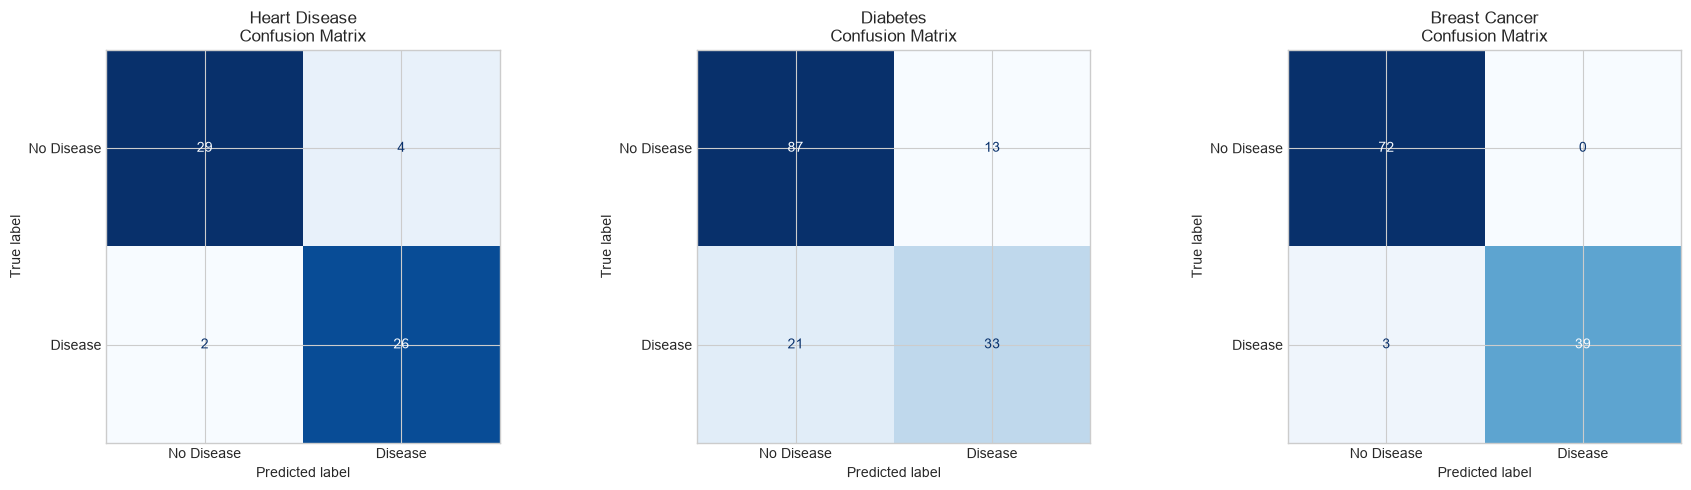

Saved → reports/confusion_matrices_all.png


In [4]:
# ── Plot all 3 confusion matrices side by side ──────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (disease_name, (model, data)) in enumerate(models.items()):
    X_train, X_test, y_train, y_test, feature_names = data
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{disease_name}\nConfusion Matrix')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → reports/confusion_matrices_all.png')

### How to read a confusion matrix

```
                Predicted: No Disease   Predicted: Disease
Actual: No Disease    True Negative         False Positive
Actual: Disease       False Negative        True Positive
```

- **Top-left & bottom-right (diagonal)** = correct predictions
- **False Negative (bottom-left)** is the MOST dangerous error in medical AI — it means we told a sick patient they're healthy
- **False Positive (top-right)** causes unnecessary worry/tests but is less dangerous than a False Negative

---
# ROC Curves — All 3 Diseases

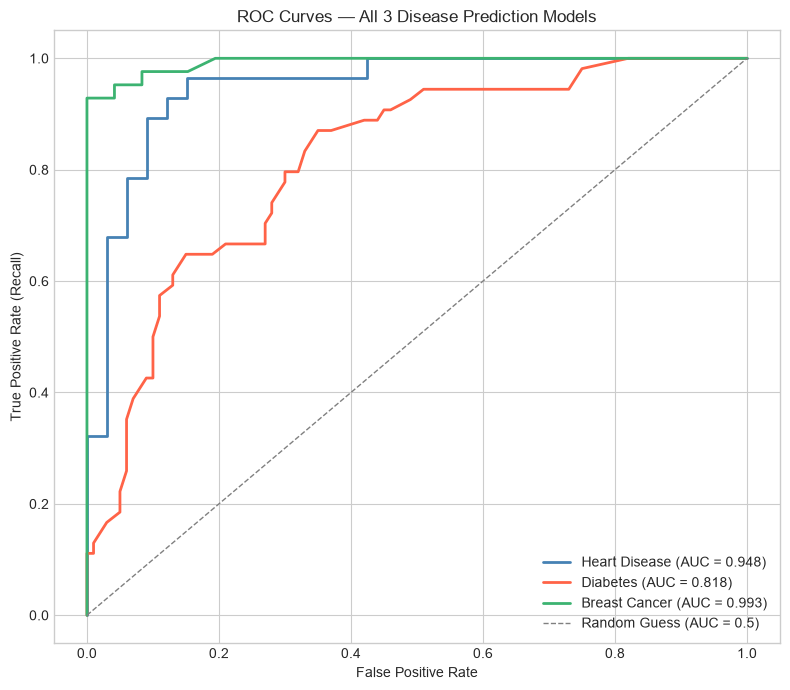

Saved → reports/roc_curves_all.png


In [5]:
# ── Plot all 3 ROC curves on one graph for easy comparison ──

plt.figure(figsize=(8, 7))

colors = ['steelblue', 'tomato', 'mediumseagreen']

for (disease_name, (model, data)), color in zip(models.items(), colors):
    X_train, X_test, y_train, y_test, feature_names = data
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{disease_name} (AUC = {roc_auc:.3f})')

# Diagonal reference line = random guessing baseline
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All 3 Disease Prediction Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → reports/roc_curves_all.png')

### How to read an ROC curve

- The closer the curve is to the **top-left corner**, the better the model
- **AUC (Area Under Curve)** summarizes this in one number: 1.0 = perfect, 0.5 = random guessing
- Our models all score well above 0.8 AUC, meaning they're much better than random guessing at separating disease vs no-disease cases

---
# Feature Importance — Which factors matter most?

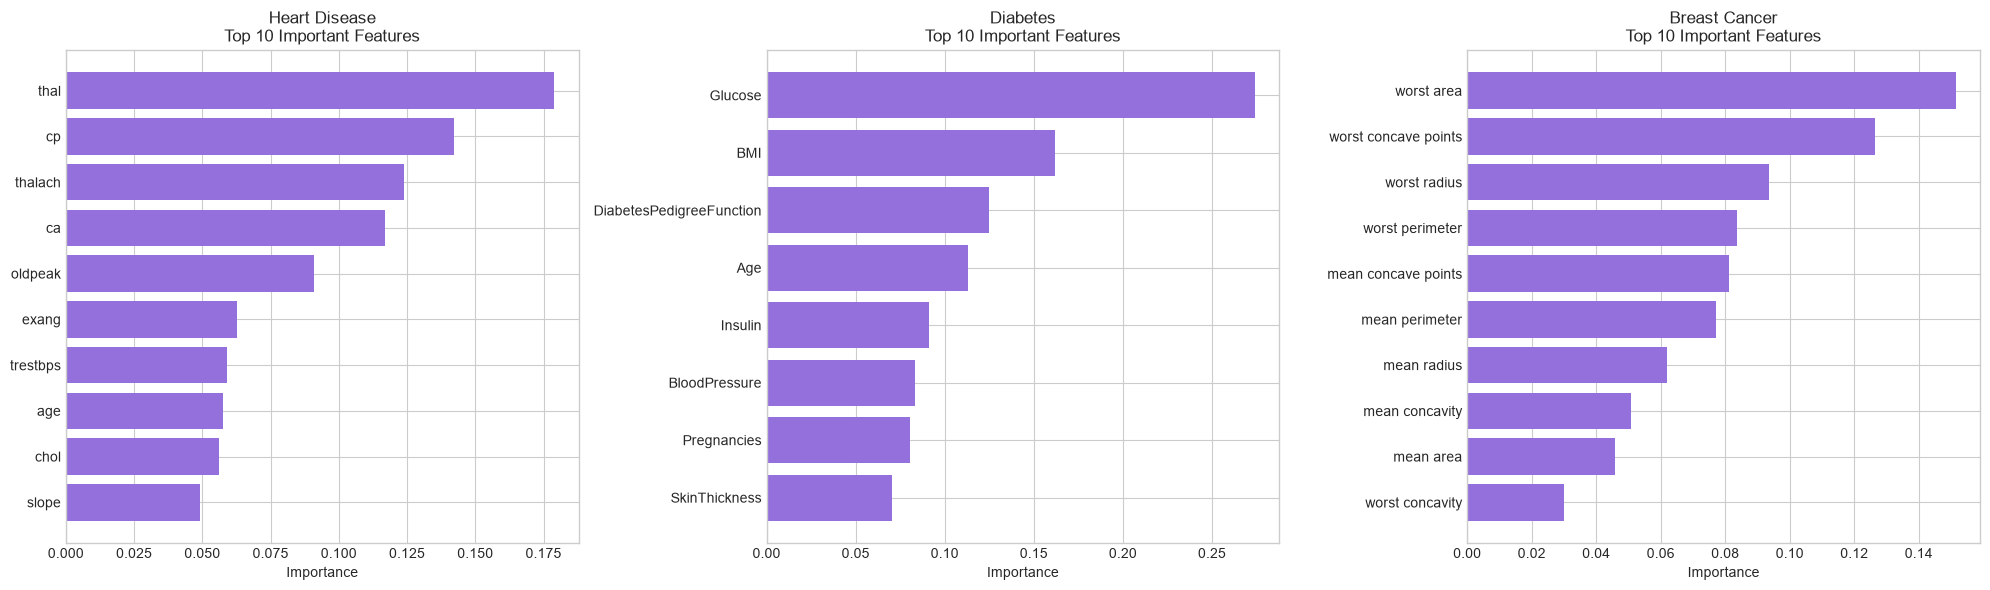

Saved → reports/feature_importance_all.png


In [6]:
# ── Random Forest gives us feature importance for free ──────
# This shows WHICH medical factors the model relies on most
# Very useful for explaining your model's decisions in interviews

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (disease_name, (model, data)) in enumerate(models.items()):
    X_train, X_test, y_train, y_test, feature_names = data

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]  # top 10 features

    axes[idx].barh(range(len(indices)), importances[indices], color='mediumpurple')
    axes[idx].set_yticks(range(len(indices)))
    axes[idx].set_yticklabels([feature_names[i] for i in indices])
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(f'{disease_name}\nTop 10 Important Features')

plt.tight_layout()
plt.savefig('../reports/feature_importance_all.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → reports/feature_importance_all.png')

---
# Summary

All evaluation visuals have been saved to the `reports/` folder:
- `confusion_matrices_all.png`
- `roc_curves_all.png`
- `feature_importance_all.png`

These are ready to use in:
- Your project report/documentation
- GitHub README (Results section)
- Resume project description / portfolio site
- Interview presentation slides